# SQ3 module-differential pipeline — stage-by-stage diagnostics\n\nExamine and validate each step before trusting the final result. Mirror of `scripts/sq3_diagnostics.py`. Run top to bottom.\n\n**Stages:** 1) incoming activity · 2) co-regulation network · 3) modules · 4) per-donor module activity · 5) differential test.

In [ ]:
%matplotlib inline
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

REPO = "/Users/ivo/workplace/research-project/bsc-screni"   # local repo path
sys.path.insert(0, os.path.join(REPO, "src"))
from screni.data.differential import _ols_with_numeric_predictor, benjamini_hochberg
from screni.data.module_preservation import leiden_modules

OUT = os.path.join(REPO, "src", "screni", "data", "output")
CTS = [("L2_3_IT", "L2/3 IT"), ("Microglia_PVM", "Microglia-PVM")]
EPS = 1e-12
COV = ("age", "sex_Male", "LATE_present", "LBD_present")

def load(ct):
    z = np.load(f"{OUT}/sq3_incoming_activity_{ct}.npz", allow_pickle=True)
    act = z["activity"].astype(float); genes = np.asarray(z["gene_names"]).astype(str)
    cond = np.asarray(z["condition"]).astype(str); cdon = np.asarray(z["donor_ids"]).astype(str)
    tgt = set(np.unique(np.asarray(np.load(f"{OUT}/per_edge_per_donor_{ct}.npz", allow_pickle=True)["targets"]).astype(str)))
    uni = np.array([g in tgt for g in genes])
    return act[:, uni], genes[uni], cond, cdon

def build_adj(cells, beta=2):
    X = cells - cells.mean(1, keepdims=True)
    keep = X.var(0) > EPS
    S = np.nan_to_num(np.corrcoef(X[:, keep].T), nan=0.0)
    A = np.abs(S) ** beta; A = (A + A.T) / 2.0; np.fill_diagonal(A, 1.0)
    return A, keep

def meta_of(ct):
    pe = np.load(f"{OUT}/per_edge_per_donor_{ct}.npz", allow_pickle=True)
    return pd.DataFrame({k: pe[k].astype(float) for k in
                         ["adnc_ordinal", "age", "sex_Male", "LATE_present", "LBD_present"]},
                        index=np.asarray(pe["donor_ids"]).astype(str))

## Stage 1 — incoming activity\nThe per-cell, per-gene input. *Look for:* is the variance dominated by *which gene* or *which cell*? Is the input reproducible?

In [ ]:
# STAGE 1 - incoming activity
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, (ct, pretty) in enumerate(CTS):
    act, genes, cond, cdon = load(ct)
    N, G = act.shape; gm = act.mean(0)
    ax = axes[row, 0]; ax.hist(gm, bins=40, color="#34495e")
    top = np.argsort(gm)[::-1][:6]
    ax.set_title(f"{pretty}: per-gene mean incoming activity\n(top: {', '.join(genes[top])})", fontsize=9)
    ax.set_xlabel("mean incoming activity"); ax.set_ylabel("# genes")
    m = act.mean(); cm = act.mean(1); gmn = act.mean(0)
    SST = ((act - m) ** 2).sum(); SS_cell = G * ((cm - m) ** 2).sum(); SS_gene = N * ((gmn - m) ** 2).sum()
    fr = np.array([SS_cell, SS_gene, SST - SS_cell - SS_gene]) / SST
    ax = axes[row, 1]
    ax.bar(["between-cell\n(global)", "between-gene", "residual"], fr, color=["#c0392b", "#2980b9", "#7f8c8d"])
    for i, v in enumerate(fr): ax.text(i, v + .01, f"{v:.0%}", ha="center", fontsize=9)
    ax.set_ylim(0, 1); ax.set_ylabel("fraction of variance"); ax.set_title(f"{pretty}: variance of incoming activity", fontsize=9)
    print(f"{pretty}: between-cell={fr[0]:.1%} between-gene={fr[1]:.1%} residual={fr[2]:.1%}")
    rng = np.random.default_rng(0); perm = rng.permutation(N)
    g1, g2 = act[perm[:N // 2]].mean(0), act[perm[N // 2:]].mean(0); r = np.corrcoef(g1, g2)[0, 1]
    ax = axes[row, 2]; ax.scatter(g1, g2, s=6, alpha=.4, color="#16a085")
    ax.set_xlabel("per-gene mean (half 1)"); ax.set_ylabel("per-gene mean (half 2)")
    ax.set_title(f"{pretty}: split-half  r={r:.3f}", fontsize=9)
plt.tight_layout(); plt.show()

**Finding:** ~85–90% of variance is *between-gene*, only ~0.5–2% *between-cell* → activity is dominated by stable per-gene baselines; the co-regulation signal lives in the ~10% residual. Per-gene split-half r≈1 is trivially high (the informative reproducibility check is on the correlation structure).

## Stage 2 — co-regulation network\nCenter, correlate genes across cells, soft-threshold. *Look for:* a dominant axis? what does centering do? how similar are the control and AD networks?

In [ ]:
# STAGE 2 - co-regulation network
beta = 2
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for row, (ct, pretty) in enumerate(CTS):
    act, genes, cond, cdon = load(ct)
    ctrl = act[cond == "control"]; adc = act[cond == "ad"]
    keep = (ctrl - ctrl.mean(1, keepdims=True)).var(0) > EPS
    Xraw = ctrl[:, keep]; Xc = Xraw - Xraw.mean(1, keepdims=True)
    Sraw = np.nan_to_num(np.corrcoef(Xraw.T), nan=0.0); S = np.nan_to_num(np.corrcoef(Xc.T), nan=0.0)
    iu = np.triu_indices(S.shape[0], k=1)
    ev = np.linalg.eigvalsh(S)[::-1]; pc1 = ev[0] / ev.sum()
    ax = axes[row, 0]; ax.bar(range(1, 11), ev[:10] / ev.sum(), color="#8e44ad")
    ax.set_title(f"{pretty}: eigen-spectrum  PC1={pc1:.0%}", fontsize=9); ax.set_xlabel("component"); ax.set_ylabel("frac variance")
    print(f"{pretty}: PC1={pc1:.1%}")
    ax = axes[row, 1]
    ax.hist(Sraw[iu], bins=60, alpha=.55, color="#e67e22", label="raw"); ax.hist(S[iu], bins=60, alpha=.55, color="#16a085", label="centered")
    ax.axvline(0, color="k", lw=.8); ax.legend(fontsize=8); ax.set_xlabel("correlation"); ax.set_ylabel("# gene pairs")
    ax.set_title(f"{pretty}: corr  raw={Sraw[iu].mean():.2f}->cent={S[iu].mean():.2f}", fontsize=9)
    kad = (adc - adc.mean(1, keepdims=True)).var(0) > EPS; both = keep & kad
    Ac = np.abs(np.nan_to_num(np.corrcoef((ctrl[:, both] - ctrl[:, both].mean(1, keepdims=True)).T), nan=0.0)) ** beta
    Aa = np.abs(np.nan_to_num(np.corrcoef((adc[:, both] - adc[:, both].mean(1, keepdims=True)).T), nan=0.0)) ** beta
    iu2 = np.triu_indices(Ac.shape[0], k=1); ac, aa = Ac[iu2], Aa[iu2]; radj = np.corrcoef(ac, aa)[0, 1]
    sub = np.random.default_rng(0).choice(len(ac), min(4000, len(ac)), replace=False)
    ax = axes[row, 2]; ax.scatter(ac[sub], aa[sub], s=4, alpha=.25, color="#2c3e50")
    lim = [0, max(ac[sub].max(), aa[sub].max())]; ax.plot(lim, lim, "r--", lw=1)
    ax.set_title(f"{pretty}: control vs AD adjacency  r={radj:.2f}", fontsize=9); ax.set_xlabel("control"); ax.set_ylabel("AD")
    print(f"{pretty}: control-vs-AD adjacency r={radj:.3f}")
plt.tight_layout(); plt.show()

**Finding:** PC1 ≈ 11% (L2/3) / 6% (microglia) → no single dominant axis. Centering is a mild shift. **control-vs-AD adjacency r ≈ 0.86 / 0.70** → the networks barely differ — foreshadows the preservation null already, at Stage 2.

## Stage 3 — module definition (Leiden on the control network)\n*Look for:* how big/many are the modules, how stable are they (across seeds), and do control and AD yield the same partition?

L2/3 IT: 11 modules>=10; seed-ARI(multi)=0.80; ctrl->ctrl ARI=0.09; ctrl->AD ARI=0.21
Microglia-PVM: 13 modules>=10; seed-ARI(multi)=0.42; ctrl->ctrl ARI=0.02; ctrl->AD ARI=0.03


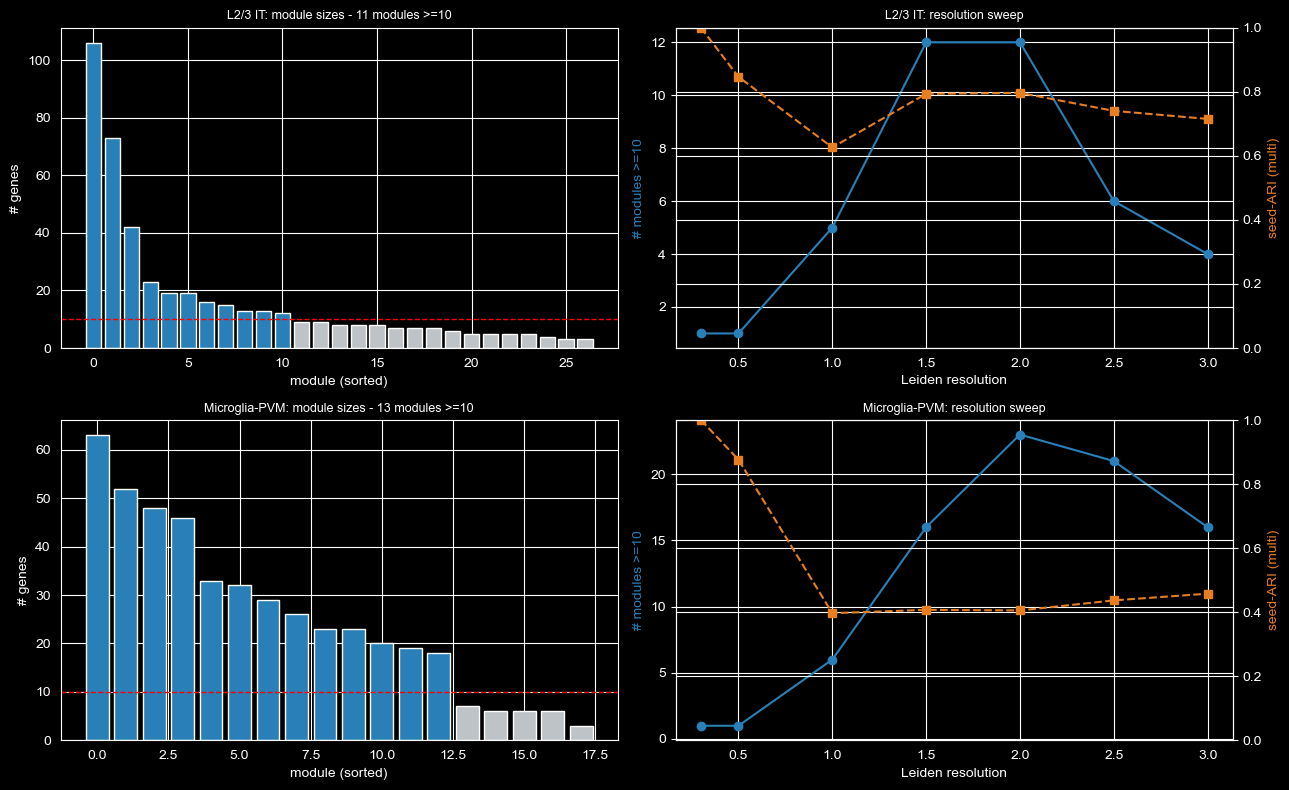

In [11]:
# STAGE 3 - module definition (Leiden on the control network)
beta, resolution = 2, 1.5
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, (ct, pretty) in enumerate(CTS):
    act, genes, cond, cdon = load(ct)
    ctrl = act[cond == "control"]; adc = act[cond == "ad"]
    A, keepc = build_adj(ctrl, beta)
    lab = leiden_modules(A, resolution=resolution, seed=42)
    sizes = np.bincount(lab); big = sizes >= 10
    ax = axes[row, 0]; ssort = np.sort(sizes[sizes >= 3])[::-1]
    ax.bar(range(len(ssort)), ssort, color=["#2980b9" if s >= 10 else "#bdc3c7" for s in ssort])
    ax.axhline(10, color="r", ls="--", lw=1); ax.set_xlabel("module (sorted)"); ax.set_ylabel("# genes")
    ax.set_title(f"{pretty}: module sizes - {int(big.sum())} modules >=10", fontsize=9)
    labs = [leiden_modules(A, resolution=resolution, seed=s) for s in range(6)]
    seed_ari = np.mean([adjusted_rand_score(labs[i], labs[j]) for i in range(6) for j in range(i + 1, 6)])
    ci = np.where(cond == "control")[0]; ai = np.where(cond == "ad")[0]; cdu = np.unique(cdon[ci])
    cc, ca = [], []
    for rep in range(3):
        rng = np.random.default_rng(rep); perm = rng.permutation(cdu)
        dA, dB = set(perm[:len(cdu)//2]), set(perm[len(cdu)//2:])
        Ac = ci[np.array([cdon[i] in dA for i in ci])]; Bc = ci[np.array([cdon[i] in dB for i in ci])]
        m = min(len(Ac), len(Bc))
        Ac = rng.choice(Ac, m, replace=False); Bc = rng.choice(Bc, m, replace=False); ad = rng.choice(ai, m, replace=False)
        keep = ((act[Ac]-act[Ac].mean(1,keepdims=True)).var(0)>EPS) & ((act[Bc]-act[Bc].mean(1,keepdims=True)).var(0)>EPS) & ((act[ad]-act[ad].mean(1,keepdims=True)).var(0)>EPS)
        pA = leiden_modules(build_adj(act[Ac][:, keep], beta)[0], resolution=resolution, seed=42)
        pB = leiden_modules(build_adj(act[Bc][:, keep], beta)[0], resolution=resolution, seed=42)
        pAD = leiden_modules(build_adj(act[ad][:, keep], beta)[0], resolution=resolution, seed=42)
        cc.append(adjusted_rand_score(pA, pB)); ca.append(adjusted_rand_score(pA, pAD))
    print(f"{pretty}: {int(big.sum())} modules>=10; seed-ARI(multi)={seed_ari:.2f}; ctrl->ctrl ARI={np.mean(cc):.2f}; ctrl->AD ARI={np.mean(ca):.2f}")
    ax = axes[row, 1]; res_list = [0.3, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]; ncount, rari = [], []
    for r in res_list:
        ls = [leiden_modules(A, resolution=r, seed=s) for s in range(5)]
        ncount.append(int((np.bincount(ls[0]) >= 10).sum()))
        rari.append(np.mean([adjusted_rand_score(ls[i], ls[j]) for i in range(5) for j in range(i + 1, 5)]))
    ax.plot(res_list, ncount, "o-", color="#2980b9"); ax.set_ylabel("# modules >=10", color="#2980b9")
    ax2 = ax.twinx(); ax2.plot(res_list, rari, "s--", color="#e67e22"); ax2.set_ylabel("seed-ARI (multi)", color="#e67e22"); ax2.set_ylim(0, 1)
    ax.set_xlabel("Leiden resolution"); ax.set_title(f"{pretty}: resolution sweep", fontsize=9)
plt.tight_layout(); plt.show()

**Finding:** ~11 (L2/3) / 13 (microglia) modules ≥10 genes. Two kinds of stability, and they differ:\n\n- *Seed stability* (same cells, different seed, multi-seed mean): **L2/3 ≈ 0.80, microglia ≈ 0.40** at res 1.5–2.0. So given a fixed cell set, L2/3 modules reproduce reasonably well; microglia's don't.\n- *Sample stability* (different cells/donors): control→control partition ARI ≈ **0.07–0.12 (L2/3), 0.02 (microglia)** — the partition is very sensitive to *which* cells go in.\n\nCrucially, **control→AD partition ARI ≈ control→control** (e.g. L2/3 res 2.0: 0.08 vs 0.07). So low control-vs-AD module agreement is **cell-sampling sensitivity, NOT a disease effect** — AD partitions disagree with control no more than two healthy halves disagree. This reconciles with Stage 2 (adjacency r=0.86): the *continuous* network is conserved; the *discrete* partition is a fragile, sample-sensitive summary of it. That is exactly why we use the **partition-free preservation test** (it scores the AD adjacency directly and has a control→control null) and **resolution-robustness**, not module identity.

### Stage 3 (optional) — biological enrichment\nValidates that modules map to real biology. Needs `gprofiler` + internet; otherwise writes gene lists for external enrichment.

In [ ]:
# STAGE 3 (optional) - biological enrichment per module. Needs the `gprofiler` package + internet.
# If absent, writes each module's gene list to output/sq3_module_genes_<ct>.txt for external enrichment.
beta, resolution = 2, 1.5
try:
    from gprofiler import GProfiler
    gp = GProfiler(return_dataframe=True)
    for ct, pretty in CTS:
        act, genes, cond, cdon = load(ct)
        A, keepc = build_adj(act[cond == "control"], beta); genes_c = genes[keepc]
        lab = leiden_modules(A, resolution=resolution, seed=42); sizes = np.bincount(lab)
        print(f"\n{pretty} top GO:BP per module:")
        for m in np.where(sizes >= 10)[0]:
            r = gp.profile(organism="hsapiens", query=genes_c[lab == m].tolist(), sources=["GO:BP"])
            print(f"  module {m} (n={sizes[m]}): {r.sort_values('p_value')['name'].iloc[0] if len(r) else '(none)'}")
except Exception as e:
    for ct, pretty in CTS:
        act, genes, cond, cdon = load(ct)
        A, keepc = build_adj(act[cond == "control"], beta); genes_c = genes[keepc]
        lab = leiden_modules(A, resolution=resolution, seed=42); sizes = np.bincount(lab)
        with open(f"{OUT}/sq3_module_genes_{ct}.txt", "w") as f:
            for m in np.where(sizes >= 10)[0]:
                f.write(f"module {m} (n={sizes[m]}): {' '.join(genes_c[lab == m])}\n")
    print(f"gprofiler not available ({type(e).__name__}); gene lists written to output/sq3_module_genes_*.txt")

## Stage 4 — per-donor module activity\nSummarize each module to one number per donor. *Look for (this is where the global trend hides):* do all modules' activities move together across donors? do they dim with severity?

L2/3 IT: mean inter-module correlation across donors = 0.94
Microglia-PVM: mean inter-module correlation across donors = 0.67


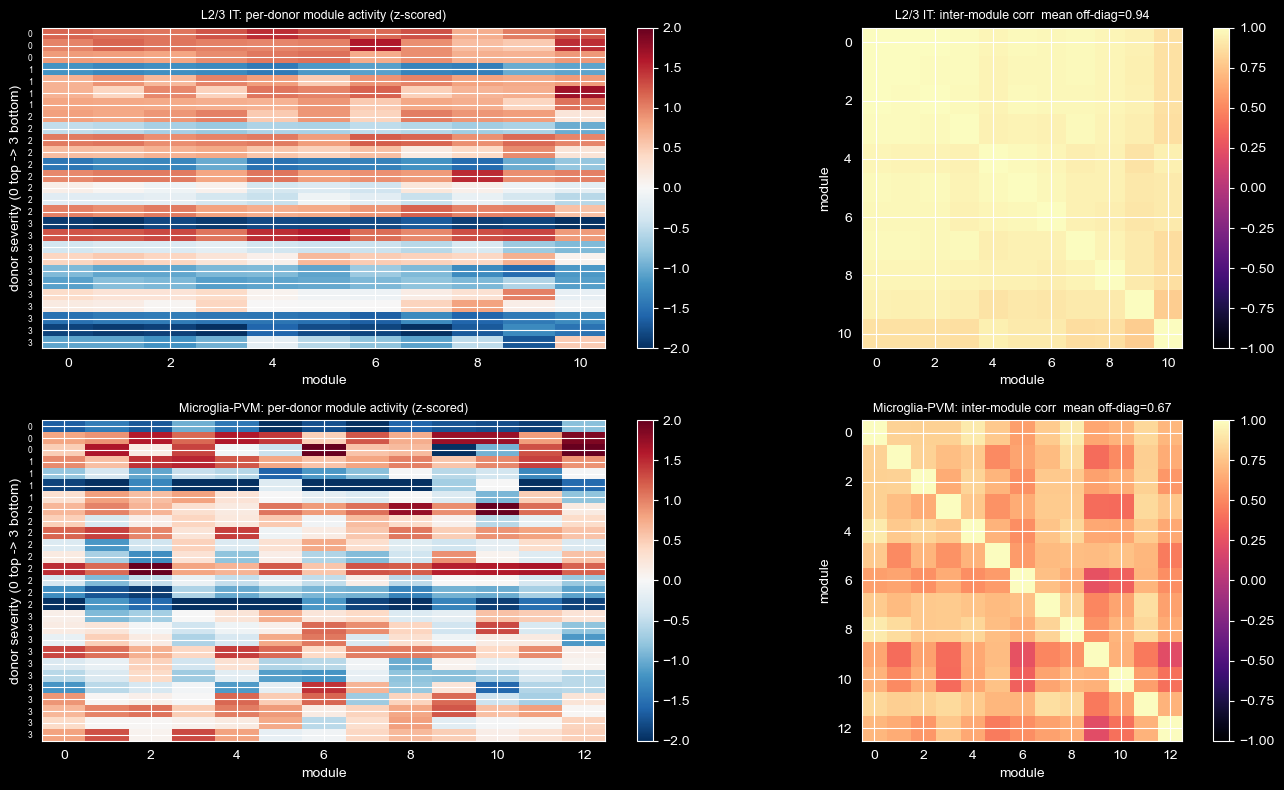

In [12]:
# STAGE 4 - per-donor module activity
beta, resolution = 2, 1.5
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, (ct, pretty) in enumerate(CTS):
    act, genes, cond, cdon = load(ct)
    meta = meta_of(ct); donors = meta.index.values; sev = meta["adnc_ordinal"].values
    A, keepc = build_adj(act[cond == "control"], beta); lab = leiden_modules(A, resolution=resolution, seed=42)
    sizes = np.bincount(lab); mods = [m for m in np.unique(lab) if sizes[m] >= 10]
    actk = act[:, keepc]; pb = np.vstack([actk[cdon == d].mean(0) for d in donors])
    modact = np.column_stack([pb[:, lab == m].mean(1) for m in mods]); order = np.argsort(sev)
    Z = (modact - modact.mean(0)) / (modact.std(0) + 1e-12)
    ax = axes[row, 0]; im = ax.imshow(Z[order], aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
    ax.set_yticks(range(len(donors))); ax.set_yticklabels(sev[order].astype(int), fontsize=6)
    ax.set_xlabel("module"); ax.set_ylabel("donor severity (0 top -> 3 bottom)")
    ax.set_title(f"{pretty}: per-donor module activity (z-scored)", fontsize=9); fig.colorbar(im, ax=ax, fraction=.046)
    C = np.corrcoef(modact.T); offmean = C[np.triu_indices_from(C, 1)].mean()
    ax = axes[row, 1]; im = ax.imshow(C, cmap="magma", vmin=-1, vmax=1)
    ax.set_title(f"{pretty}: inter-module corr  mean off-diag={offmean:.2f}", fontsize=9)
    ax.set_xlabel("module"); ax.set_ylabel("module"); fig.colorbar(im, ax=ax, fraction=.046)
    print(f"{pretty}: mean inter-module correlation across donors = {offmean:.2f}")
plt.tight_layout(); plt.show()

**Finding (the key one):** the inter-module activity correlation across donors is **0.94 in L2/3** (and 0.67 in microglia) — i.e. all modules' per-donor activities move almost in lockstep. The left heatmap shows every module dimming together as severity rises. **The global trend is visible HERE, at Stage 4, before any test** — which is precisely the between-steps insight: the per-module differential tests at Stage 5 are not independent; they all re-measure one global factor.

## Stage 5 — differential test\n*Look for:* are the per-module coefficients heterogeneous (module-specific) or all the same (global)? and do raw hits survive controlling for the global trend?

L2/3 IT: 100% same-sign; q<0.05 raw=10 controlled=0
Microglia-PVM: 54% same-sign; q<0.05 raw=0 controlled=0


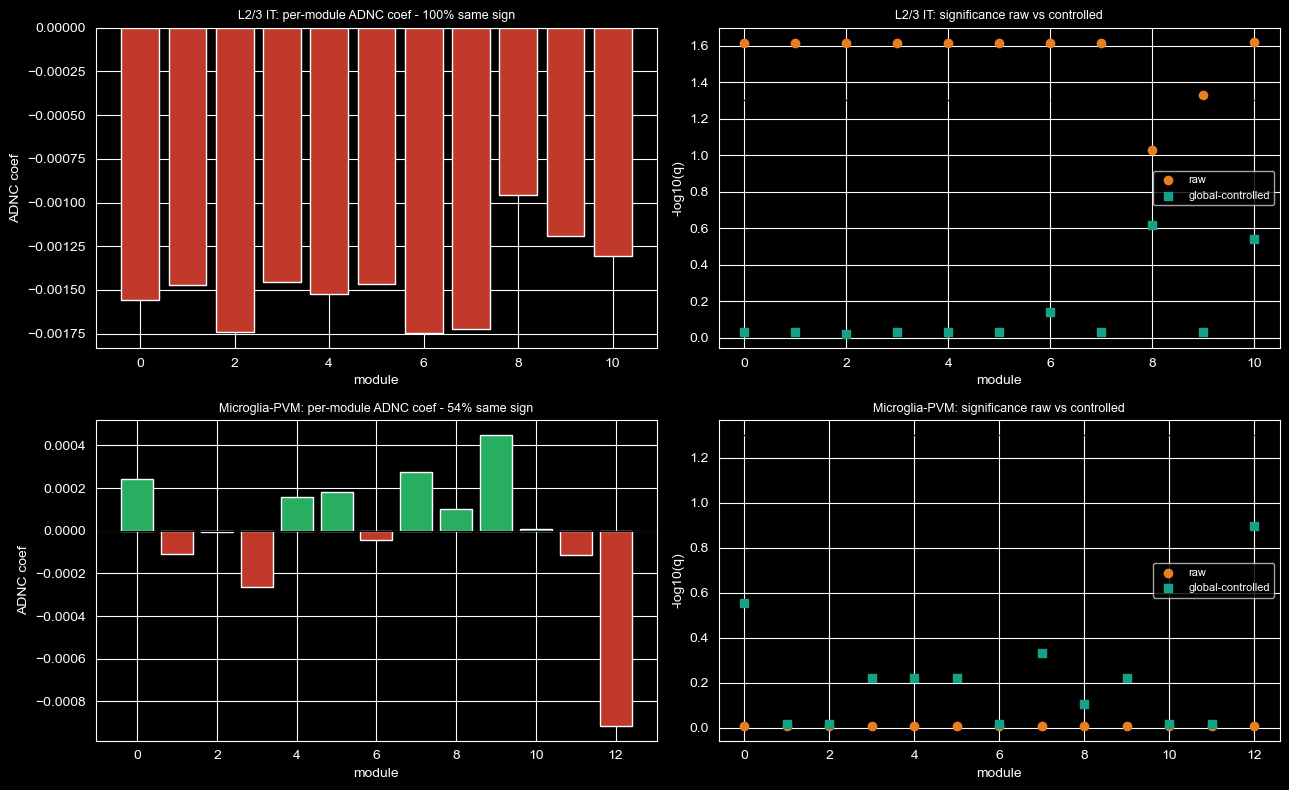

In [13]:
# STAGE 5 - differential test
beta, resolution = 2, 1.5
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, (ct, pretty) in enumerate(CTS):
    act, genes, cond, cdon = load(ct)
    meta = meta_of(ct); donors = meta.index.values
    A, keepc = build_adj(act[cond == "control"], beta); lab = leiden_modules(A, resolution=resolution, seed=42)
    sizes = np.bincount(lab); mods = [m for m in np.unique(lab) if sizes[m] >= 10]
    actk = act[:, keepc]; pb = np.vstack([actk[cdon == d].mean(0) for d in donors]); total = pb.mean(1)
    meta2 = meta.copy(); meta2["total_activity"] = total
    coefs, rawp, ctrlp = [], [], []
    for m in mods:
        ma = pb[:, lab == m].mean(1)
        coefs.append(_ols_with_numeric_predictor(ma, meta, "adnc_ordinal", covariates=COV).coef)
        rawp.append(_ols_with_numeric_predictor(ma, meta, "adnc_ordinal", covariates=COV).p_value)
        ctrlp.append(_ols_with_numeric_predictor(ma, meta2, "adnc_ordinal", covariates=COV + ("total_activity",)).p_value)
    coefs = np.array(coefs); rq = benjamini_hochberg(np.array(rawp)); cq = benjamini_hochberg(np.array(ctrlp))
    x = np.arange(len(mods)); same = max((coefs < 0).mean(), (coefs > 0).mean())
    ax = axes[row, 0]; ax.bar(x, coefs, color=["#c0392b" if c < 0 else "#27ae60" for c in coefs]); ax.axhline(0, color="k", lw=.8)
    ax.set_title(f"{pretty}: per-module ADNC coef - {same:.0%} same sign", fontsize=9); ax.set_xlabel("module"); ax.set_ylabel("ADNC coef")
    ax = axes[row, 1]; ax.scatter(x, -np.log10(rq), color="#e67e22", label="raw"); ax.scatter(x, -np.log10(cq), color="#16a085", marker="s", label="global-controlled")
    ax.axhline(-np.log10(0.05), color="k", ls="--", lw=1); ax.legend(fontsize=8); ax.set_xlabel("module"); ax.set_ylabel("-log10(q)")
    ax.set_title(f"{pretty}: significance raw vs controlled", fontsize=9)
    print(f"{pretty}: {same:.0%} same-sign; q<0.05 raw={int((rq < 0.05).sum())} controlled={int((cq < 0.05).sum())}")
plt.tight_layout(); plt.show()

**Finding:** in L2/3 **100% of module coefficients are negative** (every module declines by ~the same amount) → one global effect, not module-specific; all raw hits vanish once the global trend is controlled (raw 10 → controlled 0). Microglia coefficients are mixed-sign (~random), nothing significant. **Conclusion:** no module-specific differential effect; the only signal is the global L2/3 decline already visible at Stage 4.